In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../python')
import utils
import threepoint
from astropy.io import fits
import fitsio

### xip

In [68]:
fname = '../data/dv/meas_2pt-ave-cosmogrid.fits' # This is the mean of the 400 cosmogrid sim measurements (the version we used before Dhayaa gen 4000 sims)
xi_cg = fitsio.read(fname, ext=2)
xi_th = fitsio.read('../data/dv/sim_2pt_temp.fits', ext=2)
# use analytic cov
fname = '../data/dv/sim_2pt-NLA-cosmoCosmoG.fits'
cov = fitsio.read(fname, ext=1)[:200, :200]

In [69]:
zbins = []
for i in range(4):
    for j in range(i, 4):
        zbins.append((i+1, j+1))

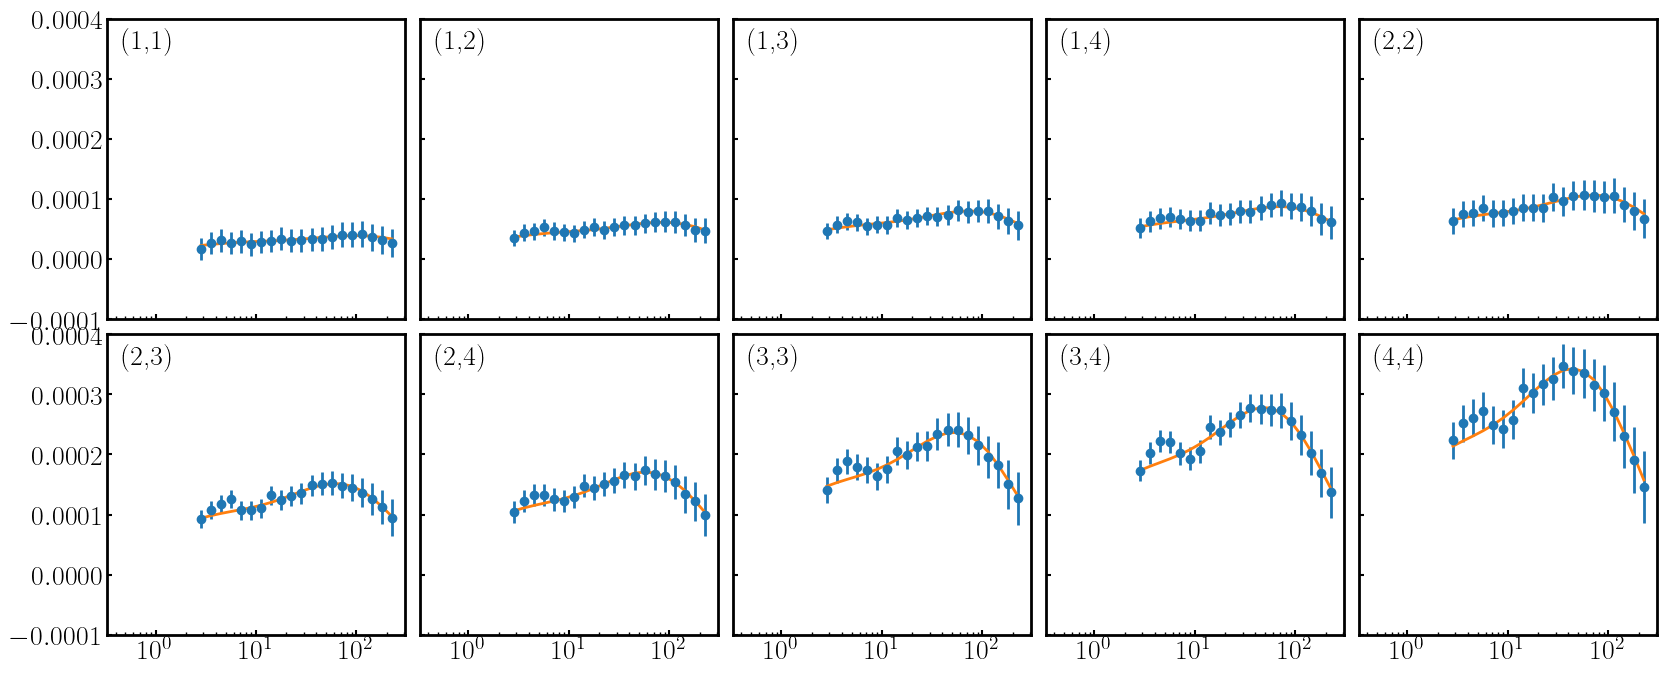

In [70]:
section_cg = np.split(xi_cg['VALUE'], 10)
section_th = np.split(xi_th['VALUE'], 10)
section_std= np.split(np.diag(cov)**0.5, 10)
ang = np.split(xi_cg['ANG'], 10)

fig, axes = plt.subplots(2,5, figsize=(20,8), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.05, hspace=0.05)
for i, ax in enumerate(axes.flatten()):
    ax.errorbar(ang[i], ang[i]*section_cg[i], ang[i]*section_std[i], label='CosmoGrid', fmt='.')
    ax.plot(ang[i], ang[i]*section_th[i], label='Theory')
    ax.set_xscale('log')
    ax.text(0.05, 0.9, '({},{})'.format(*zbins[i]), transform=ax.transAxes)
    ax.set_ylim(-1e-4, 4e-4)


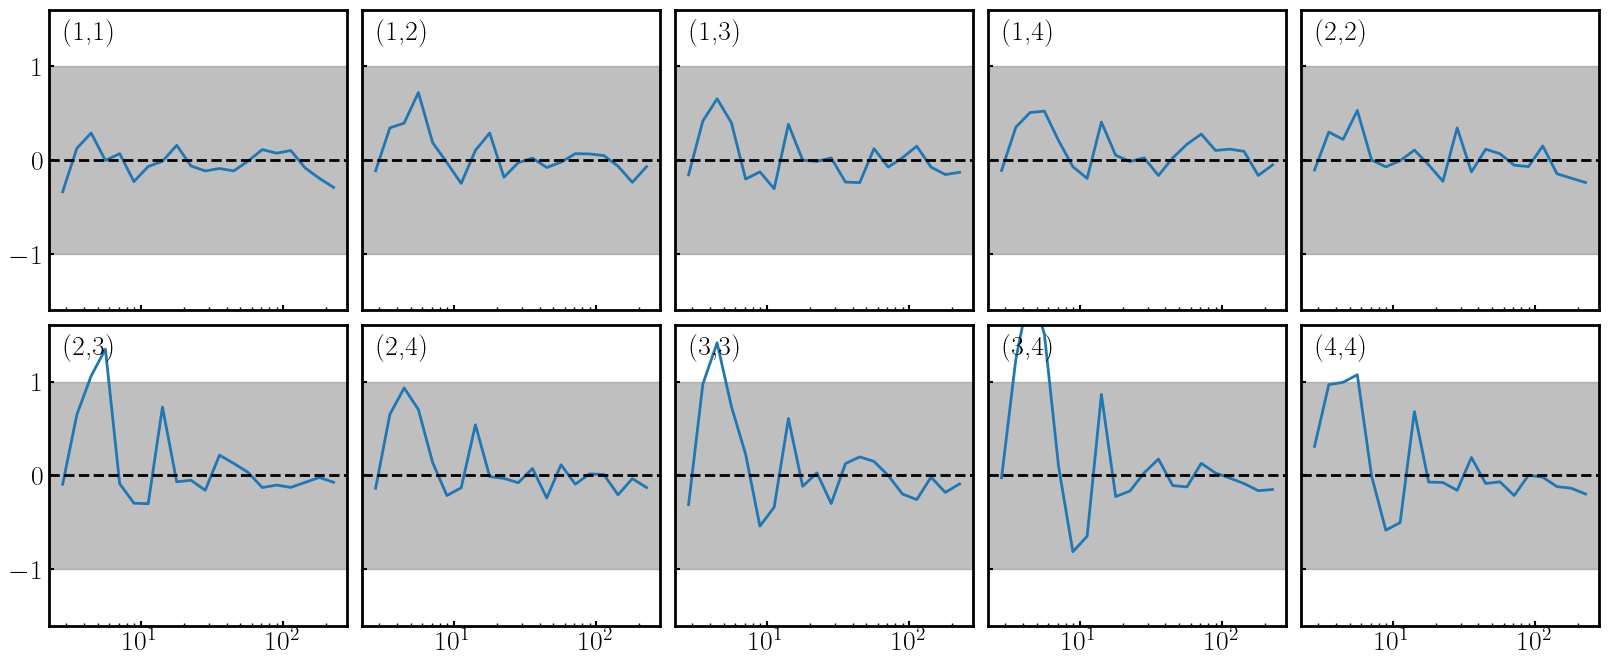

In [6]:
# residual
fig, axes = plt.subplots(2,5, figsize=(20,8), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.05, hspace=0.05)
for i, ax in enumerate(axes.flatten()):
    ax.plot(ang[i], (section_cg[i]-section_th[i])/section_std[i])
    ax.set_xscale('log')
    ax.text(0.05, 0.9, '({},{})'.format(*zbins[i]), transform=ax.transAxes)
    ax.set_ylim(-1.6, 1.6)
    ax.axhspan(-1.0, 1.0, color='gray', alpha=0.5)
    ax.axhline(0, color='k', ls='--')

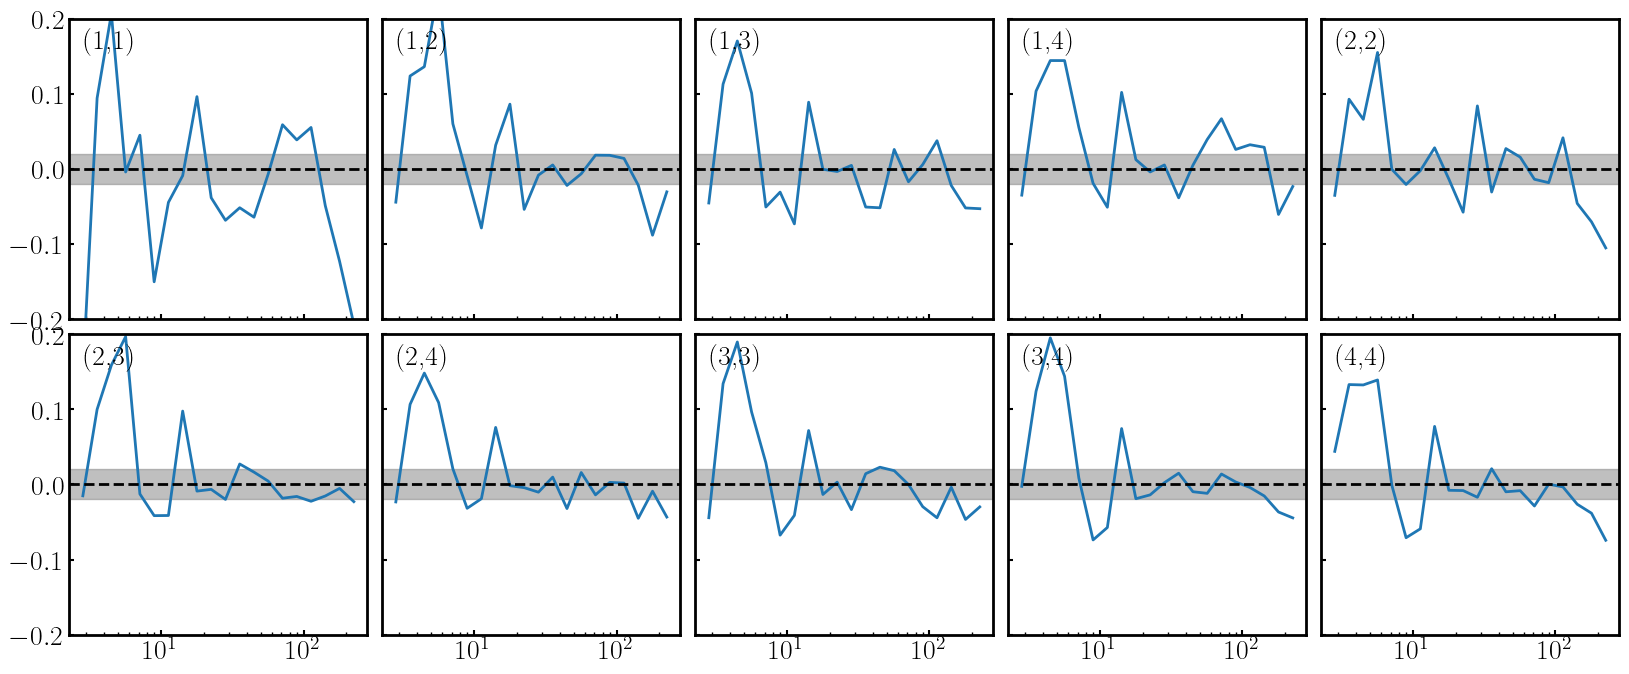

In [71]:
# residual
fig, axes = plt.subplots(2,5, figsize=(20,8), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.05, hspace=0.05)
for i, ax in enumerate(axes.flatten()):
    ax.plot(ang[i], section_cg[i]/section_th[i]-1)
    ax.set_xscale('log')
    ax.text(0.05, 0.9, '({},{})'.format(*zbins[i]), transform=ax.transAxes)
    ax.set_ylim(-0.2, 0.2)
    ax.axhspan(-0.02, 0.02, color='gray', alpha=0.5)
    ax.axhline(0, color='k', ls='--')

In [72]:
ic = np.linalg.inv(cov)
diff = xi_cg['VALUE']-xi_th['VALUE']
chi2 = diff.dot(ic).dot(diff)
chi2

28.545745595262876

## xim

In [73]:
fname = '../data/dv/meas_2pt-ave-cosmogrid.fits' # This is the mean of the 400 cosmogrid sim measurements (the version we used before Dhayaa gen 4000 sims)
# fname = '../data/dv/sim_2pt-NLA-cosmoCosmoG.fits'
xi_cg = fitsio.read(fname, ext=3)
xi_th = fitsio.read('../data/dv/sim_2pt_temp.fits', ext=3)
# cov = fitsio.read(fname, ext=1)[200:400, 200:400]
fname = '../data/dv/sim_2pt-NLA-cosmoCosmoG.fits'
cov = fitsio.read(fname, ext=1)[:200, :200]

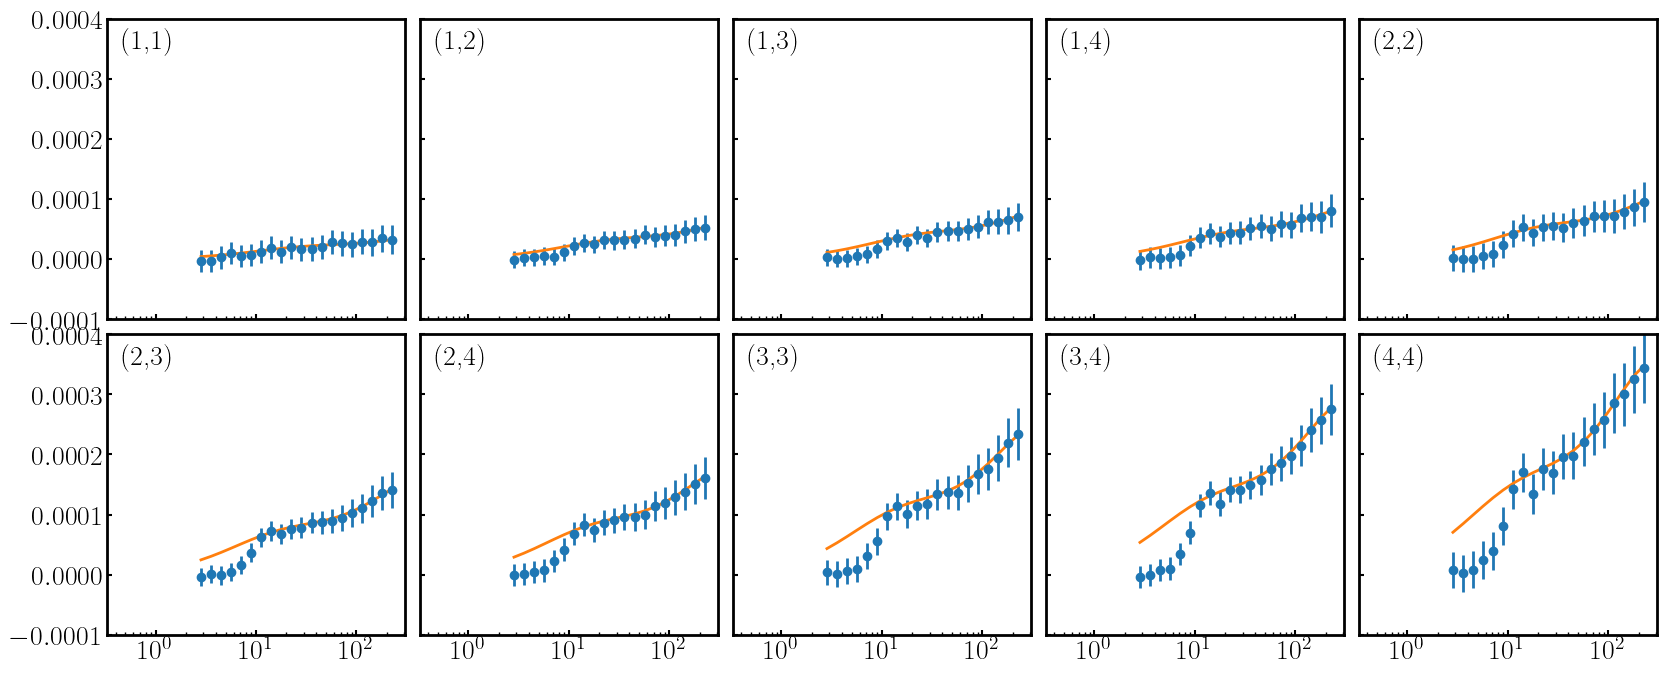

In [74]:
section_cg = np.split(xi_cg['VALUE'], 10)
section_th = np.split(xi_th['VALUE'], 10)
section_std= np.split(np.diag(cov)**0.5, 10)
ang = np.split(xi_cg['ANG'], 10)

fig, axes = plt.subplots(2,5, figsize=(20,8), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.05, hspace=0.05)
for i, ax in enumerate(axes.flatten()):
    ax.errorbar(ang[i], ang[i]*section_cg[i], ang[i]*section_std[i], label='CosmoGrid', fmt='.')
    ax.plot(ang[i], ang[i]*section_th[i], label='Theory')
    ax.set_xscale('log')
    ax.text(0.05, 0.9, '({},{})'.format(*zbins[i]), transform=ax.transAxes)
    ax.set_ylim(-1e-4, 4e-4)

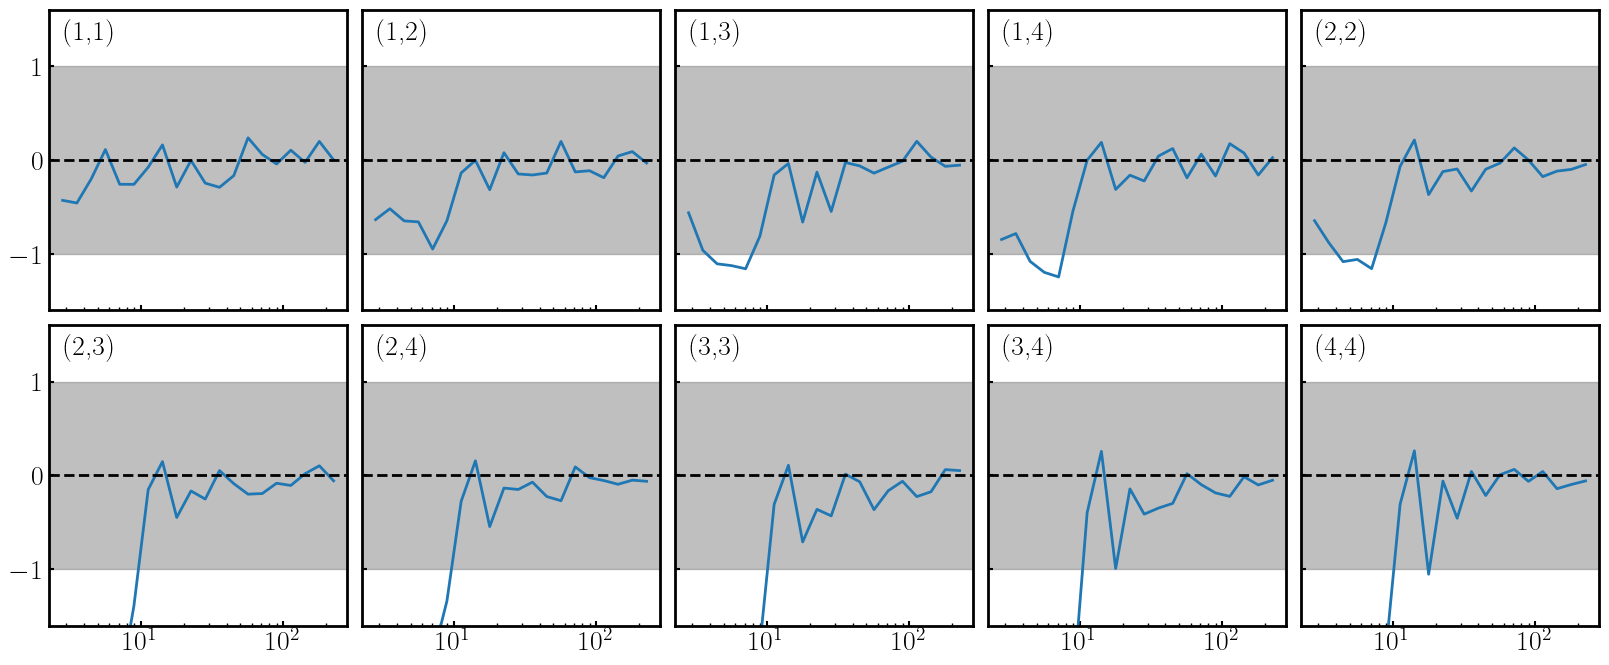

In [75]:
# residual
fig, axes = plt.subplots(2,5, figsize=(20,8), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.05, hspace=0.05)
for i, ax in enumerate(axes.flatten()):
    ax.plot(ang[i], (section_cg[i]-section_th[i])/section_std[i])
    ax.set_xscale('log')
    ax.text(0.05, 0.9, '({},{})'.format(*zbins[i]), transform=ax.transAxes)
    ax.set_ylim(-1.6, 1.6)
    ax.axhspan(-1.0, 1.0, color='gray', alpha=0.5)
    ax.axhline(0, color='k', ls='--')

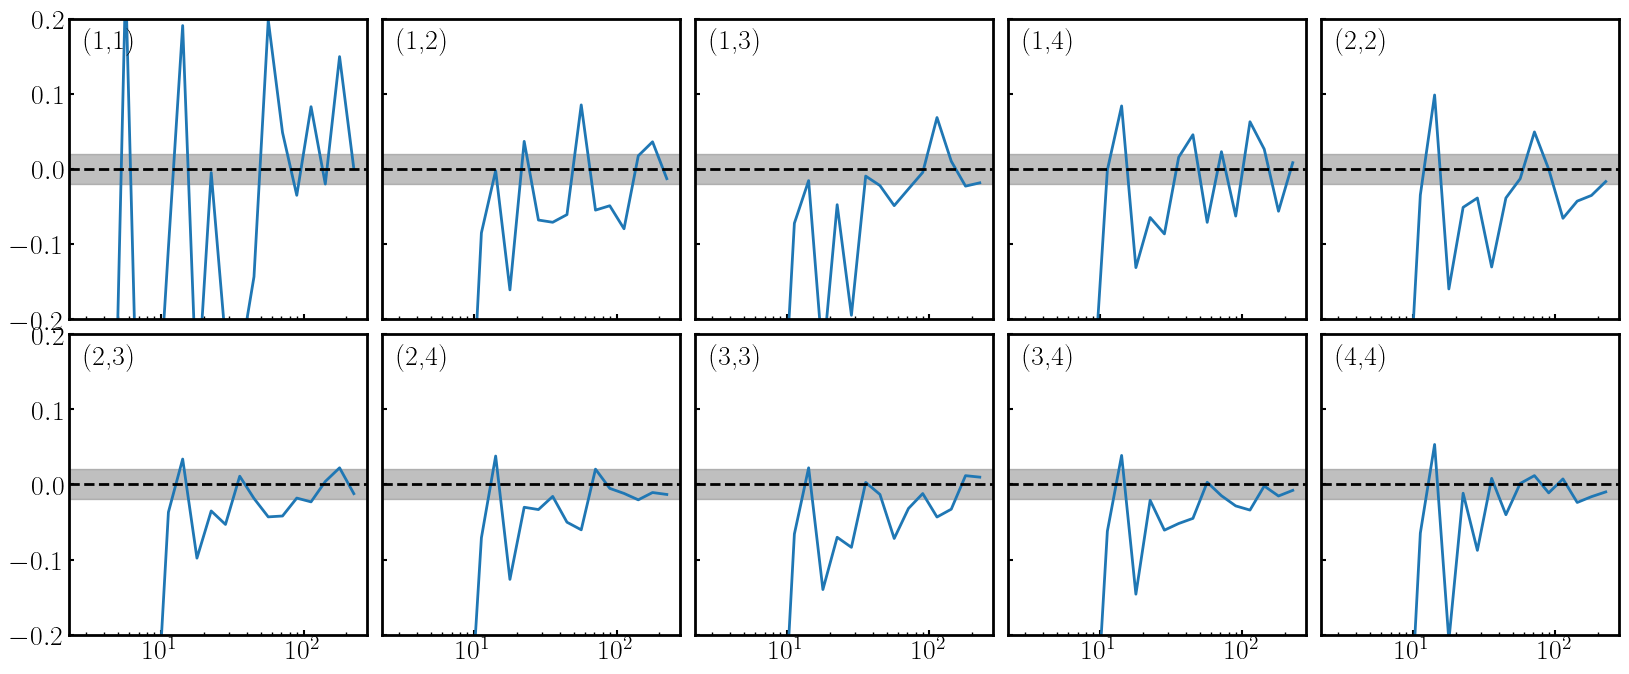

In [76]:
# residual
fig, axes = plt.subplots(2,5, figsize=(20,8), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.05, hspace=0.05)
for i, ax in enumerate(axes.flatten()):
    ax.plot(ang[i], section_cg[i]/section_th[i]-1)
    ax.set_xscale('log')
    ax.text(0.05, 0.9, '({},{})'.format(*zbins[i]), transform=ax.transAxes)
    ax.set_ylim(-0.2, 0.2)
    ax.axhspan(-0.02, 0.02, color='gray', alpha=0.5)
    ax.axhline(0, color='k', ls='--')

In [77]:
ic = np.linalg.inv(cov)
diff = xi_cg['VALUE']-xi_th['VALUE']
chi2 = diff.dot(ic).dot(diff)
chi2

146.75812744694048

## Map3

In [78]:
zbins = []
for i in range(4):
    for j in range(i, 4):
        for k in range(j, 4):
            zbins.append((i+1, j+1, k+1))

In [88]:
fname = '../data/dv/meas_map3-ave-cosmogrid.fits' # This is the mean of the 400 cosmogrid sim measurements (the version we used before Dhayaa gen 4000 sims)
map3_cg = fitsio.read(fname, ext=1)
map3_th = fitsio.read('../data/dv/sim_map3_temp_fastnc.fits', ext=1)
cov = fitsio.read(fname, ext=2)

# Now we use 632 sims out of 4000sims 
# Note that we restrict ourselves to use the 
# noise realization index only 'real'=0.
map3_cg2 = map3_cg.copy()
map3_cg2['VALUE'] =-np.loadtxt('../data/meas4k/ave_2pcf_map3_n632_noise0.dat')[400:]

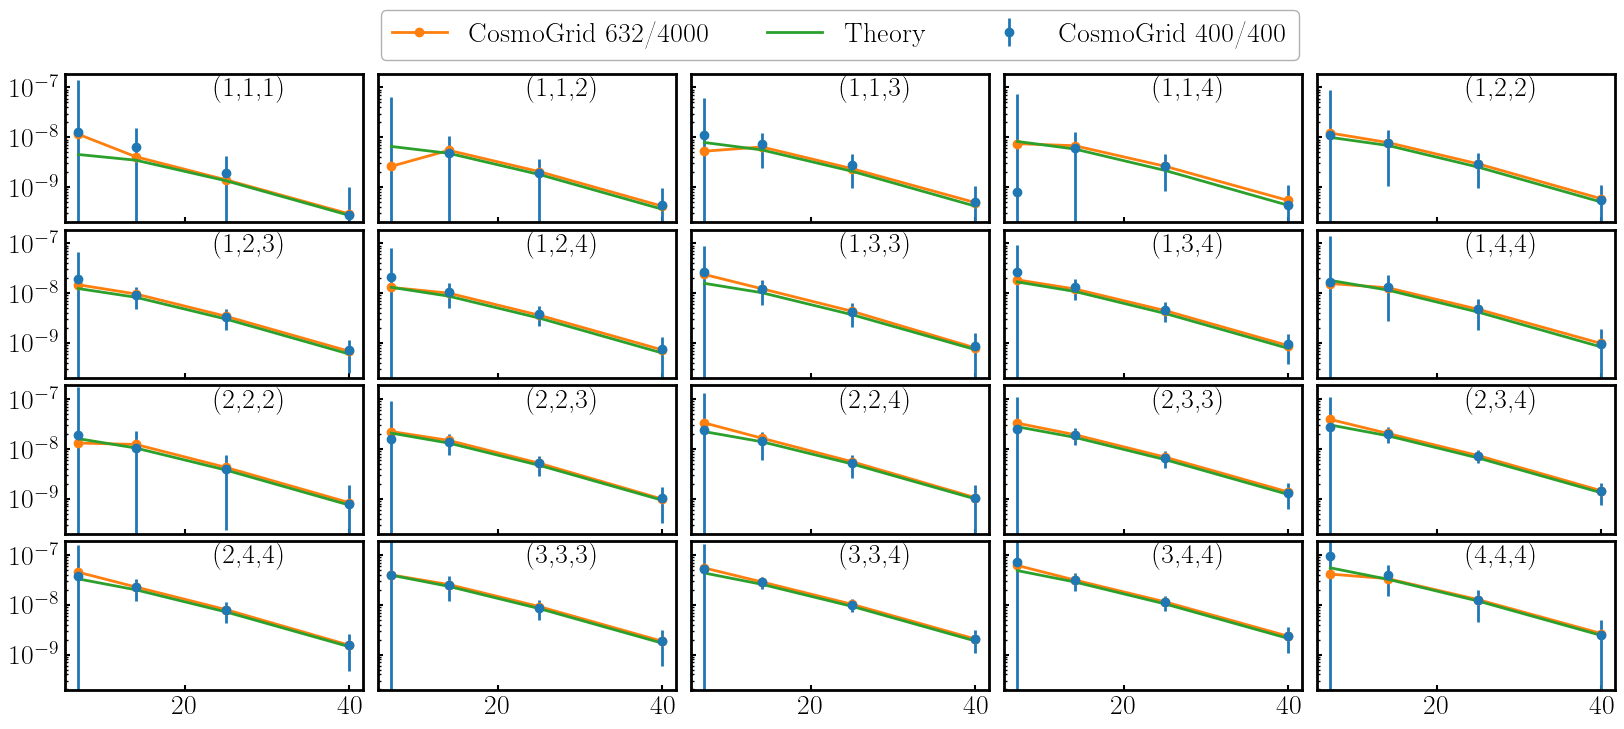

In [89]:
section_cg = np.split(map3_cg['VALUE'], 20)
section_cg2= np.split(map3_cg2['VALUE'], 20)
section_th = np.split(map3_th['VALUE'], 20)
section_std= np.split(np.diag(cov)**0.5, 20)
ang = np.split(map3_cg['THETA1'], 20)

fig, axes = plt.subplots(4,5, figsize=(20,8), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.05, hspace=0.05)
for i, ax in enumerate(axes.flatten()):
    ax.errorbar(ang[i], ang[i]*section_cg[i], ang[i]*section_std[i], label='CosmoGrid 400/400', fmt='.')
    ax.plot(ang[i], ang[i]*section_cg2[i], label='CosmoGrid 632/4000', marker='.')
    ax.plot(ang[i], ang[i]*section_th[i], label='Theory')
    ax.text(0.5, 0.85, '({},{},{})'.format(*zbins[i]), transform=ax.transAxes)
    ax.set_yscale('log')
    # ax.set_ylim(-1e-4, 4e-4)
axes[0,2].legend(loc='lower center', ncol=3, bbox_to_anchor=(0.5, 1.0))

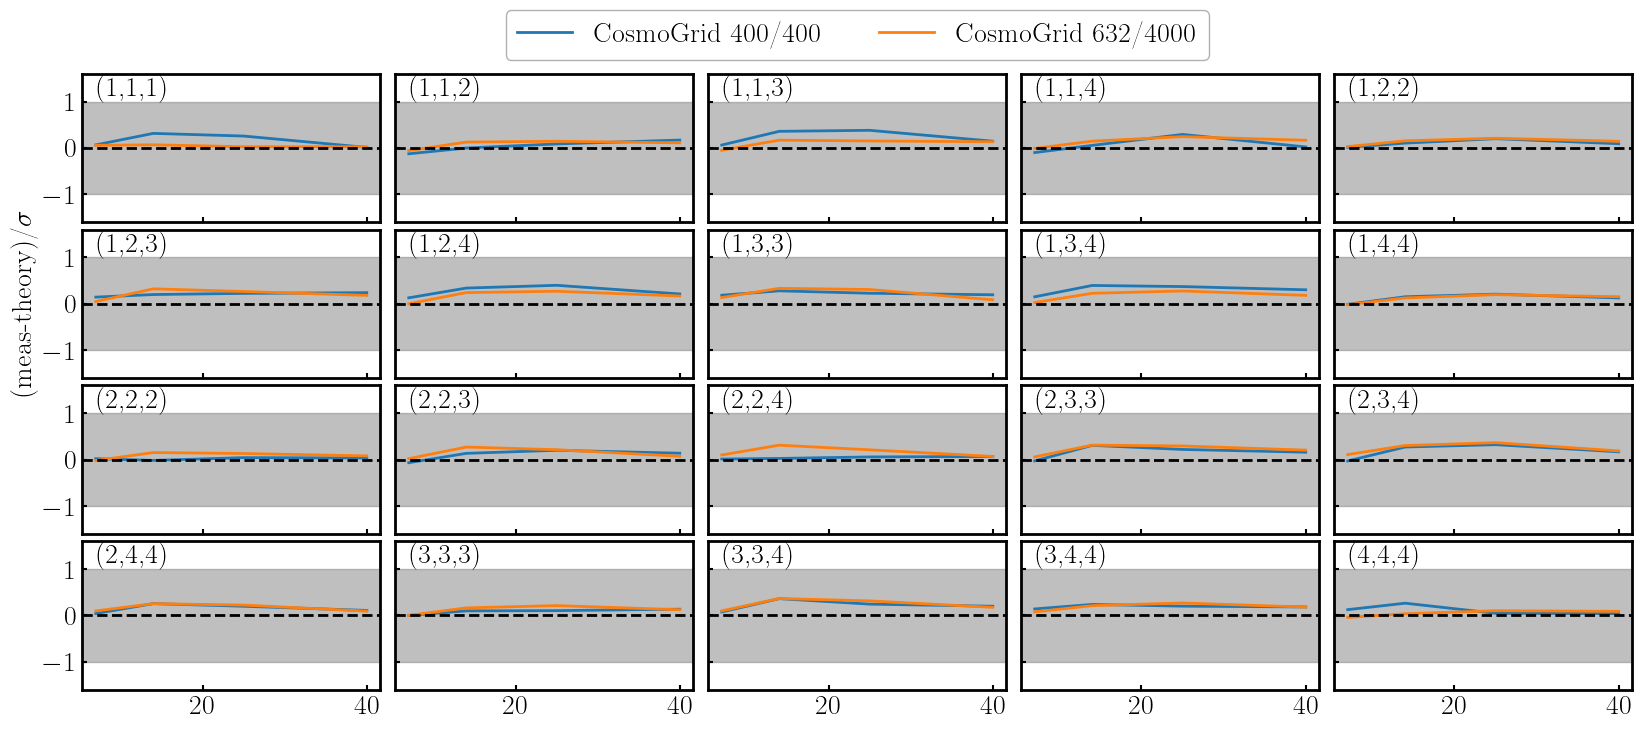

In [90]:
# residual (meas-theory)/sigma
fig, axes = plt.subplots(4,5, figsize=(20,8), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.05, hspace=0.05)
for i, ax in enumerate(axes.flatten()):
    ax.plot(ang[i], (section_cg[i]-section_th[i])/section_std[i], label='CosmoGrid 400/400')
    ax.plot(ang[i], (section_cg2[i]-section_th[i])/section_std[i], label='CosmoGrid 632/4000')
    ax.text(0.05, 0.85, '({},{},{})'.format(*zbins[i]), transform=ax.transAxes)
    ax.set_ylim(-1.6, 1.6)
    ax.axhspan(-1.0, 1.0, color='gray', alpha=0.5)
    ax.axhline(0, color='k', ls='--')
axes[1,0].set_ylabel(r'(meas-theory)/$\sigma$')
axes[0,2].legend(loc='lower center', ncol=2, bbox_to_anchor=(0.5, 1.0))

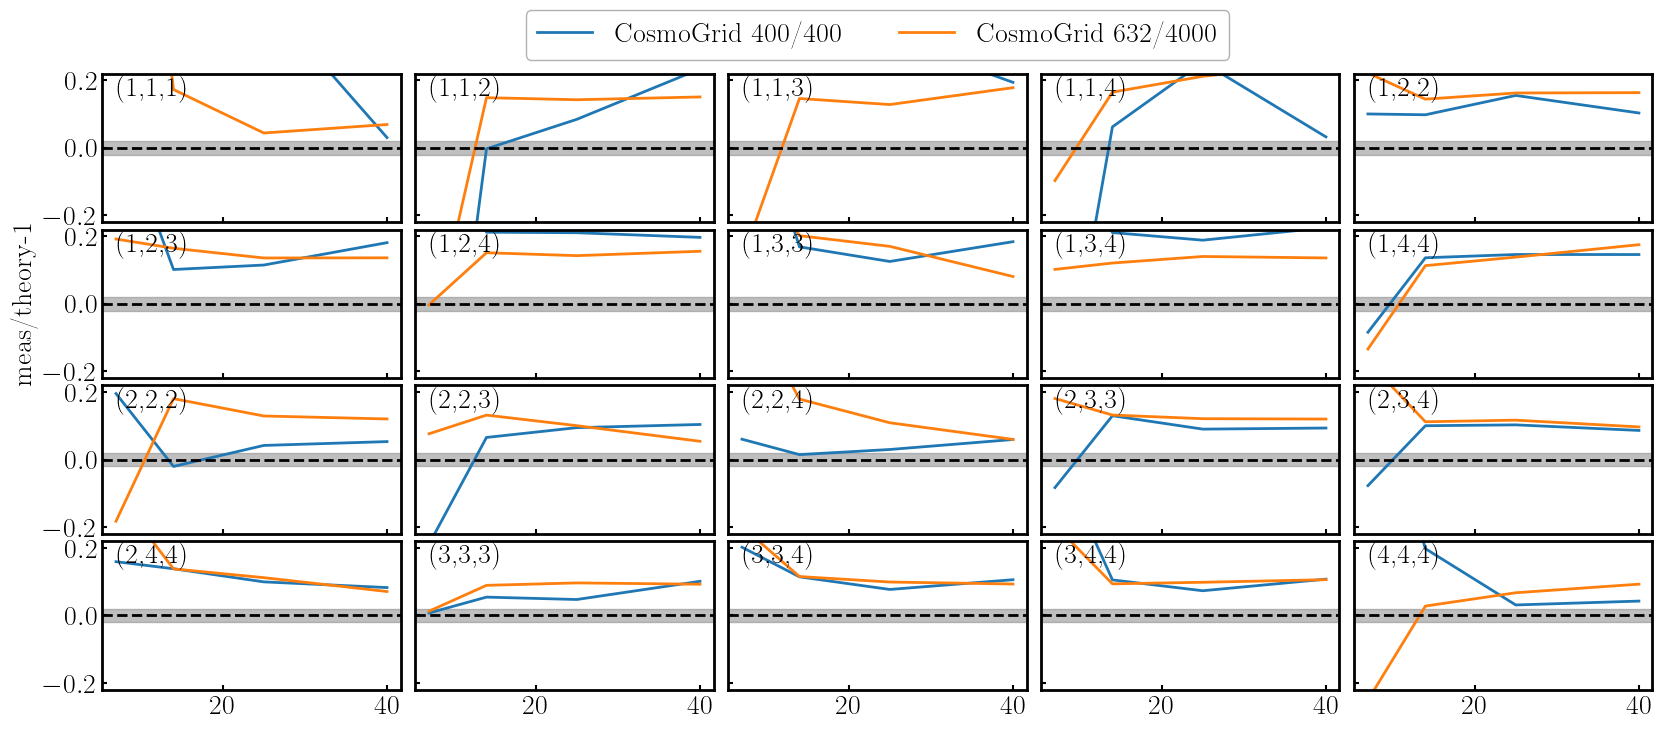

In [91]:
# residual meas/theory
fig, axes = plt.subplots(4,5, figsize=(20,8), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.05, hspace=0.05)
for i, ax in enumerate(axes.flatten()):
    ax.plot(ang[i], section_cg[i]/section_th[i]-1, label='CosmoGrid 400/400')
    ax.plot(ang[i], section_cg2[i]/section_th[i]-1, label='CosmoGrid 632/4000')
    ax.text(0.05, 0.85, '({},{},{})'.format(*zbins[i]), transform=ax.transAxes)
    ax.axhspan(-0.02, 0.02, color='gray', alpha=0.5)
    ax.axhline(0, color='k', ls='--')
    ax.set_ylim(-0.22, 0.22)
axes[1,0].set_ylabel(r'meas/theory-1')
axes[0,2].legend(loc='lower center', ncol=2, bbox_to_anchor=(0.5, 1.0))

In [92]:
ic = np.linalg.inv(cov)
diff = map3_cg['VALUE']-map3_th['VALUE']
chi2 = diff.dot(ic).dot(diff)
chi2

1.6899158692980754

In [93]:
ic = np.linalg.inv(cov)
diff = map3_cg2['VALUE']-map3_th['VALUE']
chi2 = diff.dot(ic).dot(diff)
chi2

1.0120793499889635

# Covariance

In [65]:
cov_400 = fitsio.read('../data/dv/sim_map3-NLA-cosmoDESY3.fits', 2)
cov_380 = np.loadtxt('../data/meas4k/cov_2pcf_map3_n380_noise0.dat')[400:,400:]
cov_632 = np.loadtxt('../data/meas4k/cov_2pcf_map3_n632_noise0.dat')[400:,400:]

std_400 = np.diag(cov_400)**0.5
std_380 = np.diag(cov_380)**0.5
std_632 = np.diag(cov_632)**0.5

rcc_400 = cov_400/np.outer(std_400, std_400)
rcc_380 = cov_380/np.outer(std_380, std_380)
rcc_632 = cov_632/np.outer(std_632, std_632)

0.8452296474749452

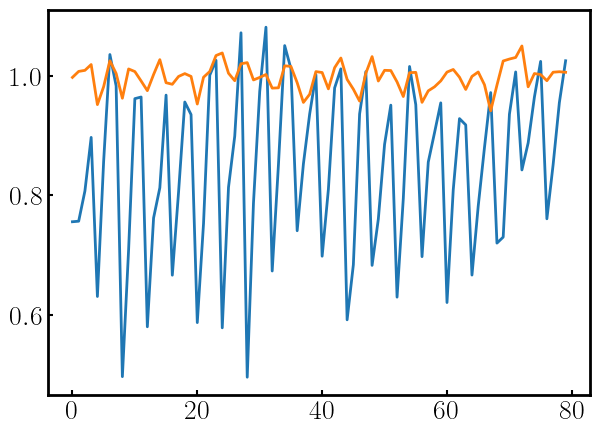

In [66]:
plt.plot(std_400/std_632)
plt.plot(std_380/std_632)
np.mean(std_400/std_632)

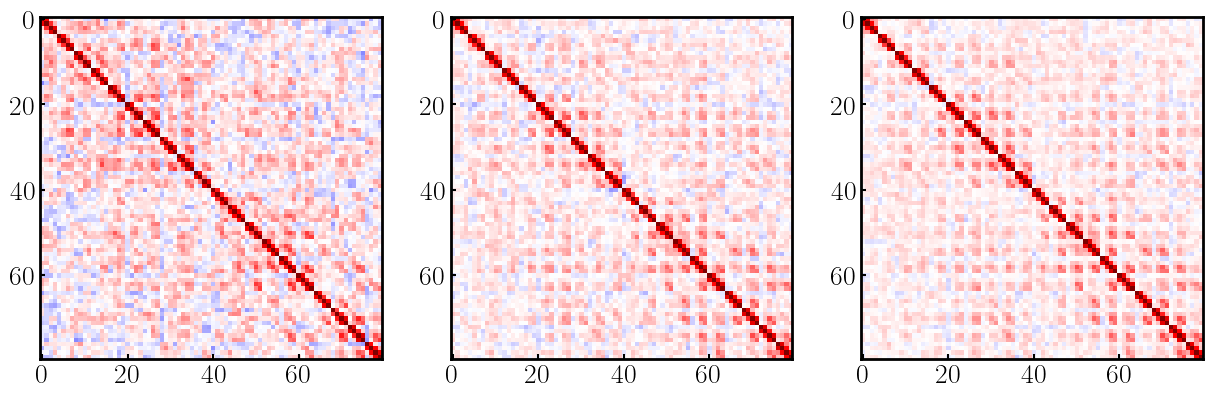

In [67]:
fig, axes = plt.subplots(1,3, figsize=(15,5))
axes[0].imshow(rcc_400, vmin=-1, vmax=1, cmap='seismic')
axes[1].imshow(rcc_380, vmin=-1, vmax=1, cmap='seismic')
axes[2].imshow(rcc_632, vmin=-1, vmax=1, cmap='seismic')
plt.show()

## NZ?

In [87]:
nzdata = fitsio.read('../data/dv/sim_2pt-NLA-cosmoDESY3.fits', 4)